In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
import yaml
import os

# Relative import for models_mae_Spat
from models_mae_Spat import spat_mae_b

# Import fourm classes
from ml_4m.fourm.vq.quantizers import VectorQuantizerLucid, Memcodes
from ml_4m.fourm.vq.vqvae import DiVAE
from ml_4m.fourm.vq.percept_losses import PerceptualLoss
from ml_4m.fourm.vq.scheduling import DDIMScheduler, PipelineCond
import matplotlib.pyplot as plt
# Import diffusion models from diffusers
from diffusers import UNet2DConditionModel, UNet2DModel
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
pip install torch torchvision pillow matplotlib scikit-image


In [ ]:
# First-test out divae is loaded perfectly
# second- to change the divae channel to 1 and test out
# check both making changes in data from 1 to 3 and reconstruct back the 3 to 1 or else make changes in the architecture to accept 1 channel
# plt all and print the reconstruction loss also

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from torchvision.transforms import Normalize
from PIL import Image
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as compare_ssim
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
import numpy as np

# Import DiVAE and utility functions
from ml_4m.fourm.vq.vqvae import DiVAE
# If IMAGENET_INCEPTION_MEAN and IMAGENET_INCEPTION_STD are defined in fourm.utils, uncomment the following line:
from ml_4m.fourm.utils import denormalize, IMAGENET_INCEPTION_MEAN, IMAGENET_INCEPTION_STD

# Define normalization parameters manually if not available in fourm.utils
# IMAGENET_INCEPTION_MEAN = [0.485, 0.456, 0.406]
# IMAGENET_INCEPTION_STD = [0.229, 0.224, 0.225]

In [ ]:
# Initialize device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
from ml_4m.fourm.vq.vqvae import DiVAE

pretrained_model_id = 'EPFL-VILAB/4M_tokenizers_rgb_16k_224-448'
print(f"Loading pretrained DiVAE model from: {pretrained_model_id}")

# Loading the pretrained model
divae = DiVAE.from_pretrained(pretrained_model_id).to(device)
divae.eval()


In [ ]:
# normalization using IMAGENET_INCEPTION_MEAN and IMAGENET_INCEPTION_STD
normalize = transforms.Normalize(mean=IMAGENET_INCEPTION_MEAN, std=IMAGENET_INCEPTION_STD)

# Define denormalization function
def denormalize_tensor(tensor, mean=IMAGENET_INCEPTION_MEAN, std=IMAGENET_INCEPTION_STD):
    mean = torch.tensor(mean).view(-1, 1, 1).to(tensor.device)
    std = torch.tensor(std).view(-1, 1, 1).to(tensor.device)
    tensor = tensor * std + mean
    return tensor


In [ ]:
def load_image(image_path, image_size=224):
    image = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        normalize,  
    ])
    image = transform(image).unsqueeze(0)  # Adding a batch dimension
    return image

# Path to your test image
test_image_path = '/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models/Screenshot 2024-11-13 190845.png'  # Replace with your image path


image_size = 224  

# Load and preprocess the image
input_image = load_image(test_image_path, image_size=image_size).to(device)
print(f"Input image shape: {input_image.shape}")  # Should be [1, 3, H, W]


In [ ]:
from PIL import Image
import torch
from torchvision import transforms

grayscale_image_path = '/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models/Screenshot 2024-11-13 190845.png'
image_size = 128

# Function to load the grayscale image and transform it
def load_grayscale_image(image_path, image_size=128):
    image = Image.open(image_path).convert('L')  # Load the image as it is (grayscale)
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),  # Convert to tensor without adding an extra RGB channel
    ])
    image = transform(image).unsqueeze(0)  # Add batch dimension
    return image

# Load the grayscale image and find its shape
input_image = load_grayscale_image(grayscale_image_path, image_size=image_size)
print(f"Input grayscale image shape: {input_image.shape}")


In [ ]:
patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)  # Shape: [1, 1, 128, 128]

# Resize if the model requires a specific size 
resize = transforms.Resize((224, 224))  
input_image = resize(patch_tensor)

In [ ]:
# Encoding the image
divae.eval()  # Ensuring the model is in evaluation mode
with torch.no_grad():
    _, _, tokens = divae.encode(input_image)
print(f"Tokens shape: {tokens.shape}")  # Should be [1, H_Q, W_Q]

In [ ]:
# Decoding the tokens
divae.use_conditioning = True  # or False, depending on the setup
with torch.no_grad():
    reconstructed_image = divae.decode_tokens(tokens, image_size=image_size, timesteps=50)
print(f"Reconstructed image shape: {reconstructed_image.shape}")  # Should be [1, 3, H, W]

In [ ]:
# Denormalize the reconstructed image
reconstructed_image_denorm = denormalize_tensor(reconstructed_image)
print(reconstructed_image_denorm.shape)

In [ ]:
def visualize_images(original, reconstructed):
    original = denormalize_tensor(original.clone()).cpu().squeeze(0)
    reconstructed = reconstructed.cpu().squeeze(0)
    
    original = torch.clamp(original, 0, 1)
    reconstructed = torch.clamp(reconstructed, 0, 1)
    
    original_np = original.permute(1, 2, 0).numpy()
    reconstructed_np = reconstructed.permute(1, 2, 0).numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(original_np)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(reconstructed_np)
    axes[1].set_title('Reconstructed Image')
    axes[1].axis('off')
    
    plt.show()

# Visualize the images
visualize_images(input_image, reconstructed_image_denorm)


In [ ]:
import torch
import numpy as np

def denormalize_tensor(tensor):
    
    return tensor * 0.5 + 0.5

def calculate_reconstruction_loss(original, reconstructed):
    # Denormalize and move to CPU
    original = denormalize_tensor(original.clone()).cpu().squeeze(0)
    reconstructed = reconstructed.cpu().squeeze(0)

    # Clamp values to [0, 1] and convert to numpy arrays
    original = torch.clamp(original, 0, 1).permute(1, 2, 0).numpy()
    reconstructed = torch.clamp(reconstructed, 0, 1).permute(1, 2, 0).numpy()

    # Calculate Mean Squared Error (MSE) as reconstruction loss
    mse_loss = np.mean((reconstructed - original) ** 2)

    return mse_loss


reconstruction_loss = calculate_reconstruction_loss(input_image, reconstructed_image_denorm)
print(f"Reconstruction Loss (MSE): {reconstruction_loss:.4f}")


In [ ]:
pip install rasterio


In [ ]:
import numpy as np
import os
from PIL import Image  # Import the Image module from Pillow

def extract_and_save_patches_as_images(file_path, output_dir, patch_size=128, num_patches=10):
    """
    Extracts and saves patches from a NumPy array loaded from an .npy file as images.

    Parameters:
    - file_path: str, path to the .npy file.
    - output_dir: str, directory to save the extracted patches.
    - patch_size: int, size of each patch (e.g., 128 for a 128x128 patch).
    - num_patches: int, number of patches to extract and save.
    """
    # Load the data from the .npy file
    data = np.load(file_path)

    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Get the dimensions of the data
    img_height, img_width = data.shape

    for i in range(num_patches):
        # Generate random starting coordinates within the image bounds
        start_x = np.random.randint(0, img_width - patch_size)
        start_y = np.random.randint(0, img_height - patch_size)

        # Extract the patch
        patch = data[start_y:start_y + patch_size, start_x:start_x + patch_size]

        # Normalize the patch data to the range [0, 255] if needed
        patch_normalized = (255 * (patch - np.min(patch)) / (np.max(patch) - np.min(patch))).astype(np.uint8)

        # Convert the patch to an image
        img = Image.fromarray(patch_normalized)

        # Save the image as a PNG file
        output_path = os.path.join(output_dir, f"patch_{i+1}.png")
        img.save(output_path)
        print(f"Saved patch {i+1} at {output_path}")

# Set file path and parameters
file_path = "/work/pi_mparente_umass_edu/data/LunarData/geochemical_maps/python/Global20ppd_LPGRS_geotiff_Ti.npy"  # Update with actual path
output_dir = "/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models"  # Directory to save patches
patch_size = 128
num_patches = 10

# Extract and save patches as images
extract_and_save_patches_as_images(file_path, output_dir, patch_size, num_patches)


In [ ]:
# test.ipynb

import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
import yaml
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np  # Added for visualization

from torchvision import transforms

# Import your SpatialModel
from model_spat import SpatialModel

# Import utility functions
from ml_4m.fourm.utils import denormalize, IMAGENET_INCEPTION_MEAN, IMAGENET_INCEPTION_STD

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define a minimal configuration dictionary
config = {
    'model': {
        'patch_size': 16,
        'image_size': 224,  # Ensure this is set to 224
        'use_ckpt': True,
        'num_tokens': 36,
        'num_channels':3 ,  # **Set to 3 for RGB input**
        'enc_mask': 0.0,
        'enc_dim': 768,
        'mask_ratio': 0.0,
        'ckpt': '/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models/hypersigma_weights/spat-vit-base-ultra-checkpoint-1599.pth',
        'spat_spec': False,
        'out_conv': True,
        'drop_path_rate': 0.0,
        'out_conv_type': 1,
        'use_diffusion': True,
        'use_conditioning': False,
        'scheduler_type': 'ddim',
    },
    'quantizer': {
        'quant_type': 'lucid',
        'latent_dim': 768,
        'codebook_size': 8192,
        'num_codebooks': 1,
        'norm_codes': True,
        'threshold_ema_dead_code': 32.0,
        'code_replacement_policy': 'batch_random',
        'sync_codebook': False,
        'ema_decay': 0.99,
        'commitment_weight': 0.25,
        'norm_latents': True,
        'kmeans_init': False,
    },
    'debug': True,
    'loss': {
        'norm_pix_loss': False,
        'use_percept': True,
        'model_id': 'vit_base_patch16_224.dino',  # Updated to the new mapping
        'feature_ids': 'blocks.2-blocks.5-blocks.8-blocks.11',
    },
    'scheduler': {
        'num_train_timesteps': 1000,
        'beta_schedule': "linear",
    },
}

# Instantiate the SpatialModel
model = SpatialModel(config).to(device)
model.eval()  # Set the model to evaluation mode

def load_sample_image(image_path):
    """
    Loads a grayscale image, resizes it to 128x128 using transforms, normalizes it, and converts to a tensor.
    
    Args:
        image_path (str): Path to the image file.
    
    Returns:
        torch.Tensor: Tensor of shape [1, 1, 128, 128].
    """
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  # Ensure it's grayscale
        transforms.Resize((128, 128)),  # Resize to 128x128
        transforms.ToTensor(),  # Convert to tensor and normalize to [0,1]
    ])
    
    image = Image.open(image_path).convert('RGB')  # Ensure image is loaded correctly
    image = transform(image)  # Shape: [1, 128, 128]
    image = image.unsqueeze(0)  # Shape: [1, 1, 128, 128]
    return image

def generate_random_grayscale_tensor(batch_size=2, image_size=128):
    """
    Generates a batch of random grayscale images.

    Args:
        batch_size (int): Number of images in the batch.
        image_size (int): Height and width of the images.

    Returns:
        torch.Tensor: Random grayscale images of shape [batch_size, 1, image_size, image_size].
    """
    # Random values between 0 and 1
    grayscale = torch.rand(batch_size, 1, image_size, image_size)
    print(f"Generated Grayscale Tensor Shape: {grayscale.shape}")  # Debug print
    return grayscale

def visualize_images(original, reconstructed, batch_index=0):
    """
    Visualizes the original and reconstructed images side by side.

    Args:
        original (torch.Tensor): Original grayscale images of shape [batch_size, 1, H, W].
        reconstructed (torch.Tensor): Reconstructed grayscale images of shape [batch_size, 1, H, W].
        batch_index (int): Index of the image in the batch to visualize.
    """
    # Squeeze the batch dimension and channel dimension
    original_image = original[batch_index].squeeze().cpu().numpy()
    reconstructed_image = reconstructed[batch_index].squeeze().cpu().numpy()

    # Clamp values to [0, 1]
    original_image = np.clip(original_image, 0, 1)
    reconstructed_image = np.clip(reconstructed_image, 0, 1)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original_image, cmap='gray')
    axes[0].set_title('Original Grayscale Image')
    axes[0].axis('off')
    
    axes[1].imshow(reconstructed_image, cmap='gray')
    axes[1].set_title('Reconstructed Grayscale Image')
    axes[1].axis('off')
    
    plt.show()

# Generate random grayscale images
image_path = '/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models/Dataset_Patches/patch_1.png'  # Replace with your image path
input_image = load_sample_image(image_path).to(device)
grayscale_images = input_image 
# generate_random_grayscale_tensor(batch_size=2, image_size=128)  # Example: Batch size of 2
print(f"Grayscale Images Shape: {grayscale_images.shape}")  # Should be [2, 1, 224, 224]

# **Duplicate channels from 1 to 3**
grayscale_images_rgb = grayscale_images.repeat(1, 3, 1, 1)
print(f"Grayscale Images After Duplication Shape: {grayscale_images_rgb.shape}")  # Should be [2, 3, 224, 224]

# Pass the grayscale images through the model
with torch.no_grad():
    spat_recon_loss, spec_recon_loss, spat_percept_loss, code_loss, tokens, reconstructed_image, _ = model(input_image.to(device))

print(f"Spatial Reconstruction Loss: {spat_recon_loss.item()}")
print(f"Spatial Perceptual Loss: {spat_percept_loss}")
print(f"Codebook Loss: {code_loss.item()}")
print(f"Tokens Shape: {tokens.shape}")
print(f"Reconstructed Image Shape: {reconstructed_image.shape}")  # Should be [2,1,224,224]

# Visualize the first image in the batch
visualize_images(grayscale_images, reconstructed_image.cpu(), batch_index=0)


Loading pretrained DiVAE model from: EPFL-VILAB/4M_tokenizers_rgb_16k_224-448
DiVAE model loaded successfully.
Printing all parameters and their shapes in the DiVAE model:
encoder.pos_emb: torch.Size([1, 768, 28, 28])
encoder.proj.weight: torch.Size([768, 3, 16, 16])
encoder.proj.bias: torch.Size([768])
encoder.blocks.0.norm1.weight: torch.Size([768])
encoder.blocks.0.norm1.bias: torch.Size([768])
encoder.blocks.0.norm2.weight: torch.Size([768])
encoder.blocks.0.norm2.bias: torch.Size([768])
encoder.blocks.0.attn.qkv.weight: torch.Size([2304, 768])
encoder.blocks.0.attn.qkv.bias: torch.Size([2304])
encoder.blocks.0.attn.proj.weight: torch.Size([768, 768])
encoder.blocks.0.attn.proj.bias: torch.Size([768])
encoder.blocks.0.mlp.fc1.weight: torch.Size([3072, 768])
encoder.blocks.0.mlp.fc1.bias: torch.Size([3072])
encoder.blocks.0.mlp.fc2.weight: torch.Size([768, 3072])
encoder.blocks.0.mlp.fc2.bias: torch.Size([768])
encoder.blocks.1.norm1.weight: torch.Size([768])
encoder.blocks.1.norm1.

/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models/ml_4m/fourm/vq/models/vit_models.py:495: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled = False):
/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models/ml_4m/fourm/vq/scheduling/diffusion_pipeline.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


Reconstructed Before Downsampling Shape: torch.Size([1, 3, 224, 224])
Downsampled Reconstructed Image Shape: torch.Size([1, 1, 128, 128])
Final Reconstruction Loss: 0.1277877241373062
Perceptual Loss Input Shapes: torch.Size([1, 1, 128, 128]), torch.Size([1, 1, 128, 128])
preds shape: torch.Size([1, 3, 128, 128])
targets shape: torch.Size([1, 3, 128, 128])
Perceptual Loss Value: 1.4224252700805664
Total Loss: 1.5502129793167114
Codebook Loss: 0.0
Tokens Shape: torch.Size([1, 14, 14])


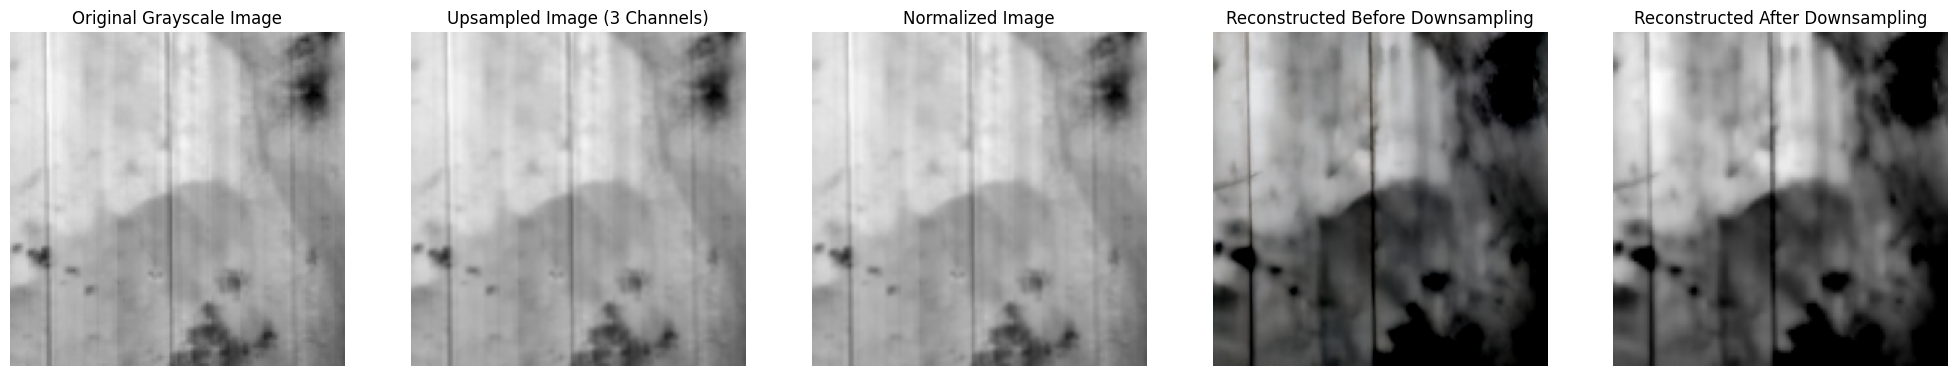

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
import yaml
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np  # For visualization
from torchvision import transforms

# Import your SpatialModel
from model_spat import SpatialModel

# Import utility functions
from ml_4m.fourm.utils import denormalize, IMAGENET_INCEPTION_MEAN, IMAGENET_INCEPTION_STD

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define the configuration dictionary (ensure it matches the one used in main.py)
config = {
    'model': {
        'patch_size': 16,
        'image_size': 224,  # Ensure this is set to 224
        'use_ckpt': True,
        'num_tokens': 36,
        'num_channels': 1,  # Set to 1 for grayscale input
        'enc_mask': 0.0,
        'enc_dim': 768,
        'mask_ratio': 0.0,
        'ckpt': '/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models/hypersigma_weights/spat-vit-base-ultra-checkpoint-1599.pth',
        'spat_spec': False,
        'out_conv': True,
        'drop_path_rate': 0.0,
        'out_conv_type': 1,
        'use_diffusion': True,
        'use_conditioning': False,
        'scheduler_type': 'ddim',
    },
    'quantizer': {
        'quant_type': 'lucid',
        'latent_dim': 768,
        'codebook_size': 8192,
        'num_codebooks': 1,
        'norm_codes': True,
        'threshold_ema_dead_code': 32.0,
        'code_replacement_policy': 'batch_random',
        'sync_codebook': False,
        'ema_decay': 0.99,
        'commitment_weight': 0.25,
        'norm_latents': True,
        'kmeans_init': False,
    },
    'debug': True,
    'loss': {
        'norm_pix_loss': False,
        'use_percept': True,
        'model_id': 'vit_base_patch16_224.dino',  # Updated to the new mapping
        'feature_ids': 'blocks.2-blocks.5-blocks.8-blocks.11',
    },
    'scheduler': {
        'num_train_timesteps': 1000,
        'beta_schedule': "linear",
    },
}

# Instantiate the SpatialModel
model = SpatialModel(config).to(device)
model.eval()  # Set the model to evaluation mode

def load_sample_image(image_path):
    """
    Loads a grayscale image, resizes it to 128x128 using transforms, normalizes it, and converts to a tensor.
    
    Args:
        image_path (str): Path to the image file.
    
    Returns:
        torch.Tensor: Tensor of shape [1, 1, 128, 128].
    """
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  # Ensure it's grayscale
        transforms.Resize((128, 128)),  # Resize to 128x128
        transforms.ToTensor(),  # Convert to tensor and normalize to [0,1]
    ])
    
    image = Image.open(image_path).convert('RGB')  # Ensure image is loaded correctly
    image = transform(image)  # Shape: [1, 128, 128]
    image = image.unsqueeze(0)  # Shape: [1, 1, 128, 128]
    return image

def visualize_images(original, upsampled, normalized, reconstructed_before_down, reconstructed_after_down):
    """
    Visualizes the original, upsampled, normalized, reconstructed before downsampling,
    and reconstructed after downsampling images side by side.
    
    Args:
        original (torch.Tensor): Original grayscale image of shape [1, 1, H, W].
        upsampled (torch.Tensor): Upsampled image of shape [1, 3, H, W].
        normalized (torch.Tensor): Normalized image of shape [1, 3, H, W].
        reconstructed_before_down (torch.Tensor): Reconstructed image before downsampling [1, 3, H, W].
        reconstructed_after_down (torch.Tensor): Reconstructed image after downsampling [1, 1, H, W].
    """
    # Squeeze the batch dimension and channel dimension where appropriate
    original_image = original.squeeze().cpu().numpy()
    upsampled_image = upsampled.squeeze().permute(1, 2, 0).cpu().numpy()  # [H, W, C]
    normalized_image = normalized.squeeze().permute(1, 2, 0).cpu().numpy()  # [H, W, C]
    reconstructed_before_down_image = reconstructed_before_down.squeeze().permute(1, 2, 0).cpu().numpy()
    reconstructed_after_down_image = reconstructed_after_down.squeeze().cpu().numpy()
    
    # For visualization, adjust the normalized image back to [0,1] range
    mean_rgb = np.array(IMAGENET_INCEPTION_MEAN).reshape(1, 1, 3)
    std_rgb = np.array(IMAGENET_INCEPTION_STD).reshape(1, 1, 3)
    normalized_image_vis = normalized_image * std_rgb + mean_rgb
    normalized_image_vis = np.clip(normalized_image_vis, 0, 1)
    
    # Clamp values to [0, 1] for visualization
    reconstructed_before_down_image = np.clip(reconstructed_before_down_image, 0, 1)
    reconstructed_after_down_image = np.clip(reconstructed_after_down_image, 0, 1)
    
    # Plotting
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    
    axes[0].imshow(original_image, cmap='gray')
    axes[0].set_title('Original Grayscale Image')
    axes[0].axis('off')
    
    axes[1].imshow(upsampled_image)
    axes[1].set_title('Upsampled Image (3 Channels)')
    axes[1].axis('off')
    
    axes[2].imshow(normalized_image_vis)
    axes[2].set_title('Normalized Image')
    axes[2].axis('off')
    
    axes[3].imshow(reconstructed_before_down_image)
    axes[3].set_title('Reconstructed Before Downsampling')
    axes[3].axis('off')
    
    axes[4].imshow(reconstructed_after_down_image, cmap='gray')
    axes[4].set_title('Reconstructed After Downsampling')
    axes[4].axis('off')
    
    plt.show()

# Replace 'path_to_sample_image.jpg' with the actual path to your sample image
image_path = '/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models/Dataset_Patches/patch_7.png'  # Replace with your image path
input_image = load_sample_image(image_path).to(device)
print(f"Grayscale Image Shape: {input_image.shape}")  # Should be [1, 1, 128, 128]

# Pass the grayscale image through the model and capture intermediate outputs
with torch.no_grad():
    print(f"Input Shape: {input_image.shape}")  # Expected: [1, 1, 128, 128]

    # Step 1: Upsample to [1, 3, 224, 224] using interpolate and repeat
    x_resized = F.interpolate(input_image, size=(224, 224), mode='bilinear', align_corners=False)  # [1,1,224,224]
    x_upsampled = x_resized.repeat(1, 3, 1, 1)  # [1,3,224,224]
    print(f"Upsampled Shape: {x_upsampled.shape}")  # [1, 3, 224, 224]

    # Step 2: Normalize the upsampled image using ImageNet Inception mean and std
    mean_rgb = torch.tensor(IMAGENET_INCEPTION_MEAN, device=device).view(1, 3, 1, 1)
    std_rgb = torch.tensor(IMAGENET_INCEPTION_STD, device=device).view(1, 3, 1, 1)
    x_normalized = (x_upsampled - mean_rgb) / std_rgb
    print(f"After Normalization Shape: {x_normalized.shape}")  # [1, 3, 224, 224]

    # Step 3: Encode the image using DiVAE's encoder and quantizer
    quant_enc, code_loss, tokens = model.divae.encode(x_normalized)

    # Step 4: Decode the tokens to reconstruct the image (Before Downsampling)
    reconstructed_before_down = model.divae.decode_tokens(
        tokens,
        timesteps=50,  # You can adjust this value
        verbose=False,
        image_size=config['model']['image_size']  # Should be 224
    )  # Shape: [1, 3, 224, 224]
    print(f"Reconstructed Before Downsampling Shape: {reconstructed_before_down.shape}")  # [1, 3, 224, 224]

    # Step 5: Downsample the reconstructed image spatially using Interpolation + Mean Channel Reduction
    # Use 'area' interpolation for downsampling to preserve details
    x_downsampled = F.interpolate(reconstructed_before_down, size=(128, 128), mode='area')  # [batch_size,3,128,128]

    # Convert from 3 channels to 1 channel by taking the mean across the channel dimension
    x_downsampled = x_downsampled.mean(dim=1, keepdim=True)  # [batch_size,1,128,128]
    print(f"Downsampled Reconstructed Image Shape: {x_downsampled.shape}")  # [batch_size,1,128,128]

    # Step 6: Compute final reconstruction loss between x_downsampled and input_image (original input)
    final_recon_loss = F.mse_loss(x_downsampled, input_image)
    print(f"Final Reconstruction Loss: {final_recon_loss.item()}")  # scalar

    # Step 7: Compute perceptual loss if enabled
    percept_loss_value = 0.0
    if model.perceptloss is not None:
        print(f"Perceptual Loss Input Shapes: {input_image.shape}, {x_downsampled.shape}")  # [1,1,128,128], [1,1,128,128]

        if model.in_channels == 1 and input_image.shape[1] == 1:
            # Duplicate original and reconstructed images to 3 channels for PerceptualLoss
            original_rgb = input_image.repeat(1, 3, 1, 1)
            reconstructed_rgb = x_downsampled.repeat(1, 3, 1, 1)
            percept_loss_value = model.perceptloss(original_rgb, reconstructed_rgb, preprocess_inputs=True)
            print(f"Perceptual Loss Value: {percept_loss_value.item()}")  # scalar
        else:
            # If already 3 channels, no duplication needed
            percept_loss_value = model.perceptloss(input_image, x_downsampled, preprocess_inputs=True)
            print(f"Perceptual Loss Value: {percept_loss_value.item()}")  # scalar

    # Step 8: Combine losses: final_recon_loss + code_loss * commitment_weight + percept_loss_value
    if config['loss']['use_percept']:
        total_loss = final_recon_loss + code_loss * config['quantizer']['commitment_weight'] + percept_loss_value
    else:
        total_loss = final_recon_loss + code_loss * config['quantizer']['commitment_weight']
    print(f"Total Loss: {total_loss.item()}")  # scalar

    # Optional: Print Codebook Loss and Tokens Shape
    print(f"Codebook Loss: {code_loss.item()}")
    print(f"Tokens Shape: {tokens.shape}")  # Should be [1, 14, 14]

    # Visualize the Images
    visualize_images(
        original=input_image,
        upsampled=x_upsampled,
        normalized=x_normalized,
        reconstructed_before_down=reconstructed_before_down,
        reconstructed_after_down=x_downsampled
    )

/home/kraju_umass_edu/.conda/envs/fourm/lib/python3.9/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading pretrained DiVAE model from: EPFL-VILAB/4M_tokenizers_rgb_16k_224-448
Froze decoder parameter: decoder.time_embed.0.weight
Froze decoder parameter: decoder.time_embed.0.bias
Froze decoder parameter: decoder.time_embed.2.weight
Froze decoder parameter: decoder.time_embed.2.bias
Froze decoder parameter: decoder.input_blocks.0.0.weight
Froze decoder parameter: decoder.input_blocks.0.0.bias
Froze decoder parameter: decoder.input_blocks.1.0.in_layers.0.weight
Froze decoder parameter: decoder.input_blocks.1.0.in_layers.0.bias
Froze decoder parameter: decoder.input_blocks.1.0.in_layers.2.weight
Froze decoder parameter: decoder.input_blocks.1.0.in_layers.2.bias
Froze decoder parameter: decoder.input_blocks.1.0.emb_layers.1.weight
Froze decoder parameter: decoder.input_blocks.1.0.emb_layers.1.bias
Froze decoder parameter: decoder.input_blocks.1.0.out_layers.0.weight
Froze decoder parameter: decoder.input_blocks.1.0.out_layers.0.bias
Froze decoder parameter: decoder.input_blocks.1.0.out_

/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models/ml_4m/fourm/vq/models/vit_models.py:495: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled = False):


preds shape: torch.Size([1, 3, 128, 128])
targets shape: torch.Size([1, 3, 128, 128])
Downsampled Reconstructed Image Shape: torch.Size([1, 1, 128, 128])
Final Reconstruction Loss: 0.12776198983192444
Perceptual Loss Value: 0.6071509718894958
Total Loss: 0.7349129915237427
Codebook Loss: 0.0


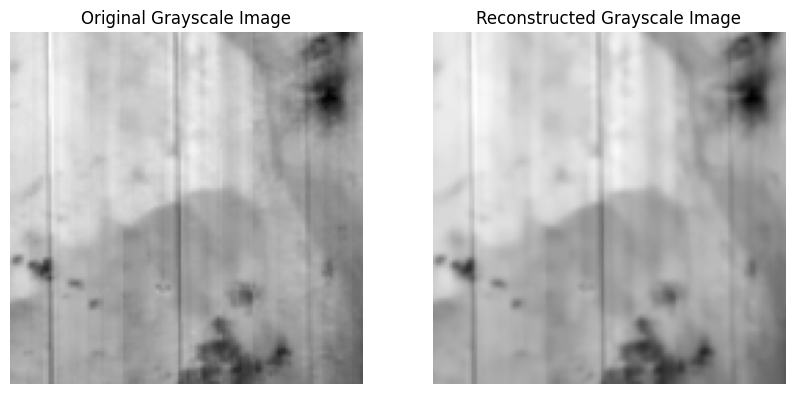

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
import yaml
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np  # For visualization
from torchvision import transforms

# Import your SpatialModel
from model_spat import SpatialModel

# Import utility functions
from ml_4m.fourm.utils import denormalize, IMAGENET_INCEPTION_MEAN, IMAGENET_INCEPTION_STD

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define the configuration dictionary (ensure it matches the one used in main.py)
config = {
    'model': {
        'patch_size': 16,
        'image_size': 256,  # Updated to 256 to match model_spat.py's upsample size
        'use_ckpt': True,
        'num_tokens': 36,
        'num_channels': 1,  # Set to 1 for grayscale input
        'enc_mask': 0.0,
        'enc_dim': 768,
        'mask_ratio': 0.0,
        'ckpt': '/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models/hypersigma_weights/spat-vit-base-ultra-checkpoint-1599.pth',
        'spat_spec': False,
        'out_conv': True,
        'drop_path_rate': 0.0,
        'out_conv_type': 1,
        'use_diffusion': True,
        'use_conditioning': False,
        'scheduler_type': 'ddim',
    },
    'quantizer': {
        'quant_type': 'lucid',
        'latent_dim': 768,
        'codebook_size': 8192,
        'num_codebooks': 1,
        'norm_codes': True,
        'threshold_ema_dead_code': 32.0,
        'code_replacement_policy': 'batch_random',
        'sync_codebook': False,
        'ema_decay': 0.99,
        'commitment_weight': 0.25,
        'norm_latents': True,
        'kmeans_init': False,
    },
    'debug': False,  # Change to True for detailed logging
    'loss': {
        'norm_pix_loss': False,
        'use_percept': True,
        'model_id': 'vit_base_patch16_224.dino',  # Ensure this matches TimmPerceptualLoss
        'feature_ids': 'blocks.2-blocks.5-blocks.8-blocks.11',
    },
    'scheduler': {
        'num_train_timesteps': 100,  # Set to 100 as per your requirement
        'beta_schedule': "linear",
        'prediction_type': "sample",  # Specify prediction type
    },
}

# Instantiate the SpatialModel
model = SpatialModel(config).to(device)
model.eval()  # Set the model to evaluation mode

def load_sample_image(image_path):
    """
    Loads a grayscale image, resizes it to 128x128 using transforms, and converts to a tensor.
    
    Args:
        image_path (str): Path to the image file.
    
    Returns:
        torch.Tensor: Tensor of shape [1, 1, 128, 128].
    """
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  # Ensure it's grayscale
        transforms.Resize((128, 128)),  # Resize to 128x128
        transforms.ToTensor(),  # Convert to tensor and normalize to [0,1]
    ])
    
    image = Image.open(image_path).convert('RGB')  # Load as RGB to ensure consistency
    image = transform(image)  # Shape: [1, 128, 128]
    image = image.unsqueeze(0)  # Shape: [1, 1, 128, 128]
    return image

def visualize_images(original, reconstructed):
    """
    Visualizes the original and reconstructed grayscale images side by side.
    
    Args:
        original (torch.Tensor): Original grayscale image of shape [1, 1, H, W].
        reconstructed (torch.Tensor): Reconstructed grayscale image of shape [1, 1, H, W].
    """
    # Squeeze the batch and channel dimensions
    original_image = original.squeeze().cpu().numpy()
    reconstructed_image = reconstructed.squeeze().cpu().numpy()
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(original_image, cmap='gray')
    axes[0].set_title('Original Grayscale Image')
    axes[0].axis('off')
    
    axes[1].imshow(reconstructed_image, cmap='gray')
    axes[1].set_title('Reconstructed Grayscale Image')
    axes[1].axis('off')
    
    plt.show()

# Replace 'path_to_sample_image.jpg' with the actual path to your sample image
image_path = '/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models/Dataset_Patches/patch_7.png'  # Replace with your image path
input_image = load_sample_image(image_path).to(device)
print(f"Grayscale Image Shape: {input_image.shape}")  # Should be [1, 1, 128, 128]

# Create nan_mask (assuming all valid, i.e., no NaNs)
nan_mask = torch.zeros_like(input_image).to(device)

# Pass the grayscale image through the model and capture outputs
with torch.no_grad():
    print(f"Input Shape: {input_image.shape}")  # Expected: [1, 1, 128, 128]
    
    # Forward pass through the model
    total_loss, final_recon_loss, percept_loss_value, code_loss, _, x_downsampled, _ = model(
        input_image,
        nan_mask=nan_mask
    )
    
    print(f"Downsampled Reconstructed Image Shape: {x_downsampled.shape}")  # [1,1,128,128]
    
    # Step 6: Compute final reconstruction loss between x_downsampled and input_image (original input)
    # Already computed as final_recon_loss
    print(f"Final Reconstruction Loss: {final_recon_loss.item()}")  # scalar
    
    # Step 7: Compute perceptual loss if enabled
    if config['loss']['use_percept']:
        print(f"Perceptual Loss Value: {percept_loss_value.item()}")  # scalar
    else:
        percept_loss_value = 0.0
    
    # Step 8: Combine losses: final_recon_loss + code_loss * commitment_weight + percept_loss_value
    if config['loss']['use_percept']:
        total_loss_value = final_recon_loss + code_loss * config['quantizer']['commitment_weight'] + percept_loss_value
    else:
        total_loss_value = final_recon_loss + code_loss * config['quantizer']['commitment_weight']
    print(f"Total Loss: {total_loss_value.item()}")  # scalar
    
    # Optional: Print Codebook Loss and Tokens Shape
    print(f"Codebook Loss: {code_loss.item()}")
    
    # Visualize the Original and Reconstructed Images
    visualize_images(
        original=input_image,
        reconstructed=x_downsampled
    )


In [3]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
import yaml
import os
from PIL import Image
import matplotlib.pyplot as plt

# Relative import for models_mae_Spat
from models.models_mae_Spat import spat_mae_b

# Import fourm classes
from models.ml_4m.fourm.vq.quantizers import VectorQuantizerLucid, Memcodes
from models.ml_4m.fourm.vq.vqvae import DiVAE
from models.percept_loss import TimmPerceptualLoss
from models.ml_4m.fourm.vq.scheduling import DDIMScheduler, PipelineCond

# Import diffusion models from diffusers
from diffusers import UNet2DConditionModel, UNet2DModel
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Import utility functions
from models.ml_4m.fourm.utils import denormalize, IMAGENET_INCEPTION_MEAN, IMAGENET_INCEPTION_STD
# Load the pretrained DiVAE model
pretrained_model_id = 'EPFL-VILAB/4M_tokenizers_rgb_16k_224-448'
print(f"Loading pretrained DiVAE model from: {pretrained_model_id}")
divae = DiVAE.from_pretrained(pretrained_model_id).to(device)
print("DiVAE model loaded successfully.")
divae.eval()
print(divae)

Loading pretrained DiVAE model from: EPFL-VILAB/4M_tokenizers_rgb_16k_224-448
DiVAE model loaded successfully.
DiVAE(
  (encoder): ViTEncoder(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
      (1): Block(


In [ ]:
import pickle
import os

# Define paths
root = "/work/pi_mparente_umass_edu/data/LunarData/"
name = "geochemical_maps"
pkl_path = os.path.join(root, "selected_patches", f"{name}.pkl")

# Load the .pkl file
with open(pkl_path, 'rb') as f:
    selected_patches = pickle.load(f)

# Inspect keys and number of patches
print("Available Files in selected_patches.pkl:")
print(selected_patches.keys())

fileName = 'Global20ppd_LPGRS_geotiff_Ti'
if fileName in selected_patches:
    print(f"Number of patches for {fileName}: {selected_patches[fileName].shape[0]}")
else:
    print(f"Error: {fileName} not found in selected_patches.pkl")


In [ ]:
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
from model_spat import SpatialModel

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define the configuration dictionary
config = {
    'model': {
        'patch_size': 16,
        'image_size': 224,
        'use_ckpt': True,
        'num_tokens': 36,
        'num_channels': 1,
        'enc_mask': 0.0,
        'enc_dim': 768,
        'mask_ratio': 0.0,
        'ckpt': '/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models/hypersigma_weights/spat-vit-base-ultra-checkpoint-1599.pth',
        'spat_spec': False,
        'out_conv': True,
        'drop_path_rate': 0.0,
        'out_conv_type': 1,
        'use_diffusion': True,
        'use_conditioning': False,
        'scheduler_type': 'ddim',
    },
    'quantizer': {
        'quant_type': 'lucid',
        'latent_dim': 768,
        'codebook_size': 8192,
        'num_codebooks': 1,
        'norm_codes': True,
        'threshold_ema_dead_code': 32.0,
        'code_replacement_policy': 'batch_random',
        'sync_codebook': False,
        'ema_decay': 0.99,
        'commitment_weight': 0.25,
        'norm_latents': True,
        'kmeans_init': False,
    },
    'debug': True,
    'loss': {
        'norm_pix_loss': False,
        'use_percept': True,
        'model_id': 'vit_base_patch16_224.dino',
        'feature_ids': 'blocks.2-blocks.5-blocks.8-blocks.11',
    },
    'scheduler': {
        'num_train_timesteps': 1000,
        'beta_schedule': "linear",
    },
}

# Instantiate the SpatialModel
model = SpatialModel(config).to(device)
model.eval()  # Set the model to evaluation mode

def load_sample_image(image_path):
    """
    Loads a grayscale image, resizes it to 128x128 using transforms, normalizes it, and converts to a tensor.
    """
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  # Ensure it's grayscale
        transforms.Resize((128, 128)),  # Resize to 128x128
        transforms.ToTensor(),  # Convert to tensor and normalize to [0,1]
    ])
    image = Image.open(image_path).convert('RGB')  # Ensure image is loaded correctly
    image = transform(image)  # Shape: [1, 128, 128]
    image = image.unsqueeze(0)  # Shape: [1, 1, 128, 128]
    return image

def visualize_results(original, reconstructed, downsampled, total_loss):
    """
    Visualizes the original, reconstructed, and downsampled images.
    """
    original_image = original.squeeze().cpu().numpy()
    reconstructed_image = reconstructed.squeeze().permute(1, 2, 0).cpu().numpy()  # [H, W, C]
    downsampled_image = downsampled.squeeze().cpu().numpy()
    
    # Clamp reconstructed images to [0, 1] for visualization
    reconstructed_image = reconstructed_image.clip(0, 1)
    downsampled_image = downsampled_image.clip(0, 1)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(original_image, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(reconstructed_image)
    axes[1].set_title('Reconstructed Image')
    axes[1].axis('off')
    
    axes[2].imshow(downsampled_image, cmap='gray')
    axes[2].set_title(f'Downsampled Image\nTotal Loss: {total_loss:.4f}')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Replace 'path_to_sample_image.jpg' with the actual path to your sample image
image_path = '/home/kraju_umass_edu/Tokenizer/H3Tokenizer/models/Dataset_Patches/patch_7.png'  # Replace with your image path
input_image = load_sample_image(image_path).to(device)
print(f"Input Image Shape: {input_image.shape}")  # Should be [1, 1, 128, 128]

# Pass the image through the model and visualize results
with torch.no_grad():
    # Call the SpatialModel's forward function
    spat_recon_loss, _, spat_percept_loss, code_loss, _, downsampled, _ = model(
        input_image
    )

    # Combine the losses
    total_loss = (
        spat_recon_loss
        + code_loss * config['quantizer']['commitment_weight']
        + (spat_percept_loss.mean() if config['loss']['use_percept'] else 0)
    )

    # Use the downsampled output as the reconstructed image for visualization
    visualize_results(
        original=input_image,
        reconstructed=downsampled,  # Use the downsampled tensor here
        downsampled=downsampled,
        total_loss=total_loss.item()
    )

    print(f"Reconstruction Loss: {spat_recon_loss.item()}")
    print(f"Perceptual Loss: {spat_percept_loss.mean().item() if config['loss']['use_percept'] else 0}")
    print(f"Codebook Loss: {code_loss.item()}")
    print(f"Total Loss: {total_loss.item()}")
